In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#data
df = pd.read_csv("/content/data.csv")
target_col = "Restormel 10SRE01"
time_features = ["hour", "day_of_week", "month", "day", "is_weekend"]
all_features = [target_col] + time_features
df = df[all_features]
num_features = len(all_features)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.index = pd.date_range("2024-01-01", periods=len(df_scaled), freq="H")
df_scaled.index.name = "datetime"

#sliding window params
seq_len = 1344
label_len = 336
pred_len = 1344
stride = 12

/tmp/ipython-input-1-3764107005.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_scaled.index = pd.date_range("2024-01-01", periods=len(df_scaled), freq="H")


In [2]:
from sklearn.model_selection import train_test_split
def create_sliding_windows(df, target_col, seq_len, label_len, pred_len, stride):
    import numpy as np
    data_np = df.to_numpy()
    target_index = df.columns.get_loc(target_col)

    X_enc, X_dec, Y = [], [], []

    for i in range(0, len(data_np) - seq_len - pred_len, stride):
        seq_x = data_np[i:i + seq_len].copy()
        seq_y_init = data_np[i + seq_len - label_len:i + seq_len].copy()
        dec_in = np.concatenate([
            data_np[i + seq_len - label_len : i + seq_len],  # last `label_len` context
            np.zeros((pred_len, num_features))
        ], axis=0)
        target_seq = data_np[i + seq_len:i + seq_len + pred_len, target_index]

        X_enc.append(seq_x)
        X_dec.append(dec_in)
        Y.append(np.array(target_seq).reshape(pred_len))

    return np.array(X_enc), np.array(X_dec), np.array(Y)



X_enc, X_dec, Y = create_sliding_windows(df_scaled, target_col, seq_len, label_len, pred_len, stride)

X_enc_train, X_enc_val, X_dec_train, X_dec_val, Y_train, Y_val = train_test_split(
    X_enc, X_dec, Y, test_size=0.2, random_state=42
)


In [3]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, MultiHeadAttention, Add, Concatenate
import tensorflow as tf


class LearnablePositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_embedding = self.add_weight(
            name="pos_embedding",
            shape=(1, max_len, d_model),
            initializer="random_normal",
            trainable=True
        )
    def call(self, x):
        return x + self.pos_embedding[:, :tf.shape(x)[1], :]

def transformer_block(x, context, d_model, num_heads, ff_dim, dropout_rate, causal=False):
    x_ln = LayerNormalization(epsilon=1e-6)(x)
    context_ln = LayerNormalization(epsilon=1e-6)(context)
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(
        x_ln, context_ln, use_causal_mask=causal)
    x = Add()([x, Dropout(dropout_rate)(attn_output)])

    ff_ln = LayerNormalization(epsilon=1e-6)(x)
    ff_output = Dense(ff_dim, activation='relu')(ff_ln)
    ff_output = Dropout(dropout_rate)(ff_output)
    ff_output = Dense(d_model)(ff_output)
    return Add()([x, Dropout(dropout_rate)(ff_output)])


def build_temporal_transformer_forecaster(seq_len, label_len, pred_len, num_features,
                                          d_model=128, num_heads=8, ff_dim=512,
                                          dropout_rate=0.3, num_layers=4, loss_fn='huber'):
    # Inputs
    enc_input = Input(shape=(seq_len, num_features))
    dec_input = Input(shape=(label_len + pred_len, num_features))

    # Project features
    x_enc = Dense(d_model)(enc_input)
    x_dec = Dense(d_model)(dec_input)

    # Add positional encodings
    x_enc = LearnablePositionalEncoding(seq_len, d_model)(x_enc)
    x_dec = LearnablePositionalEncoding(label_len + pred_len, d_model)(x_dec)

    # Encoder stack
    for _ in range(num_layers):
        x_enc = transformer_block(x_enc, x_enc, d_model, num_heads, ff_dim, dropout_rate)

    # Decoder stack (causal)
    for _ in range(num_layers):
        x_dec = transformer_block(x_dec, x_enc, d_model, num_heads, ff_dim, dropout_rate, causal=True)

    #gated residual fusion
    fused = Concatenate()([x_dec[:, -pred_len:, :], x_enc[:, -pred_len:, :]])
    fused = Dense(d_model, activation="relu")(fused)

    #MLP forecast head
    x = Dense(256, activation='relu')(fused)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(1)(x)
    model = Model(inputs=[enc_input, dec_input], outputs=x)

    # loss selection
    if loss_fn == 'mae':
        loss = tf.keras.losses.MeanAbsoluteError()
    elif loss_fn == 'mse':
        loss = tf.keras.losses.MeanSquaredError()
    else:
        loss = tf.keras.losses.Huber()
    #compile
    model.compile(optimizer="adam", loss=loss, metrics=["mae"])
    return model


In [4]:
d_model = 64
num_features = X_enc.shape[2]

model = build_temporal_transformer_forecaster(
    seq_len=1344,
    label_len=336,
    pred_len=1344,
    num_features=X_enc.shape[2],
    d_model=64,
    num_heads=8,
    ff_dim=512,
    dropout_rate=0.3,
    num_layers=4,
    loss_fn="huber"
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(factor=0.5, patience=5)

model.fit(
    [X_enc_train, X_dec_train], Y_train,
    validation_data=([X_enc_val, X_dec_val], Y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - loss: 0.4005 - mae: 0.7433 - val_loss: 0.3326 - val_mae: 0.6605 - learning_rate: 0.0010
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - loss: 0.3353 - mae: 0.6607 - val_loss: 0.3349 - val_mae: 0.6635 - learning_rate: 0.0010
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.3240 - mae: 0.6457 - val_loss: 0.3215 - val_mae: 0.6482 - learning_rate: 0.0010
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.3133 - mae: 0.6326 - val_loss: 0.3038 - val_mae: 0.6202 - learning_rate: 0.0010
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.3094 - mae: 0.6275 - val_loss: 0.2962 - val_mae: 0.6062 - learning_rate: 0.0010
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.2928 - mae: 0.6030 - val_loss: 0.2906 - val_mae: 0.5960 - learning_rate: 0.0010
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.2901 - mae: 0.6012 - val_loss: 0.2811 - val_mae: 0.5897 - learning_rate: 0.0010


4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
MAE: 1.12
MSE: 2.78
R² Score: 0.9849


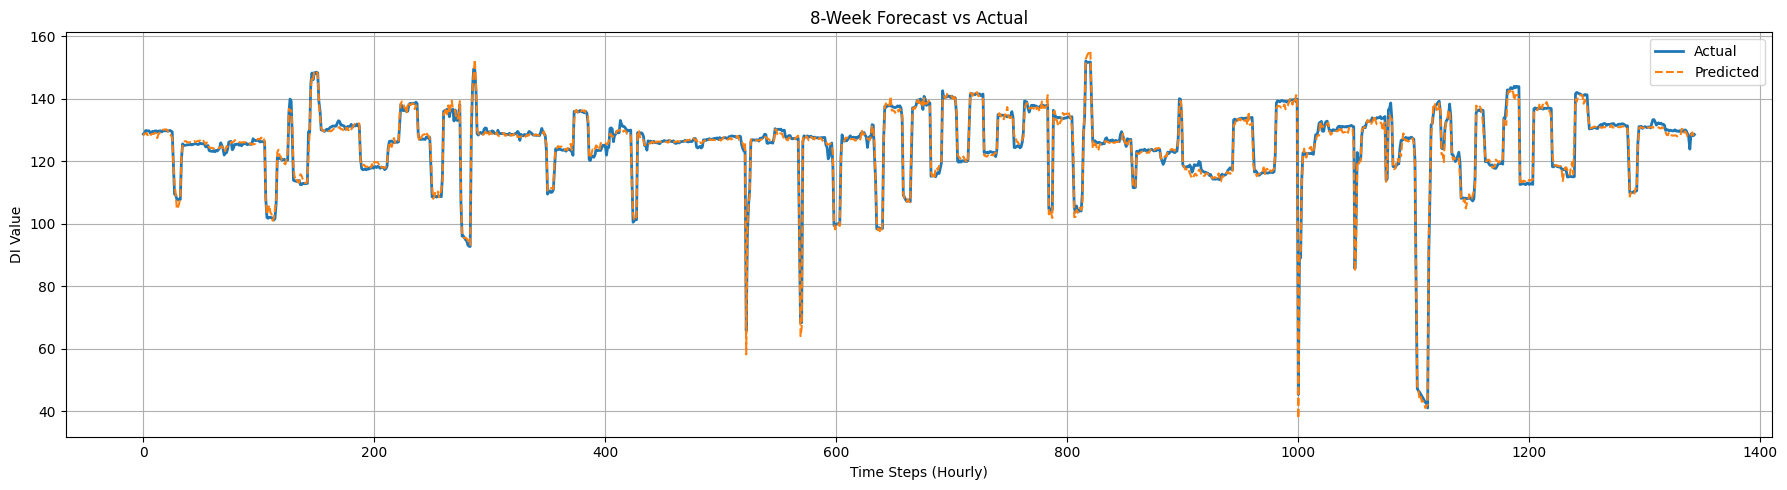

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#predict
Y_pred_scaled = model.predict([X_enc_val, X_dec_val])


Y_pred_flat = Y_pred_scaled.reshape(-1, 1)
Y_true_flat = Y_val.reshape(-1, 1)

#inverse transform
target_index = df.columns.get_loc(target_col)
n_features = df.shape[1]

Y_pred_full = np.zeros((Y_pred_flat.shape[0], n_features))
Y_true_full = np.zeros_like(Y_pred_full)

Y_pred_full[:, target_index] = Y_pred_flat[:, 0]
Y_true_full[:, target_index] = Y_true_flat[:, 0]

Y_pred_unscaled = scaler.inverse_transform(Y_pred_full)[:, target_index]
Y_true_unscaled = scaler.inverse_transform(Y_true_full)[:, target_index]

#metrics
mae = mean_absolute_error(Y_true_unscaled, Y_pred_unscaled)
mse = mean_squared_error(Y_true_unscaled, Y_pred_unscaled)
r2 = r2_score(Y_true_unscaled, Y_pred_unscaled)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

#plot of predictions vs actuals
plt.figure(figsize=(18, 5))
plt.plot(Y_true_unscaled[:1344], label='Actual', linewidth=2)
plt.plot(Y_pred_unscaled[:1344], label='Predicted', linestyle='--')
plt.title('8-Week Forecast vs Actual')
plt.xlabel('Time Steps (Hourly)')
plt.ylabel('DI Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
